In [1]:
%load_ext autoreload
%autoreload 2

# Part 3: Loss Functions
In this notebook, the goal is:
* **Visualizing the harshness:** Comparing how aggressively MSE (use for regression) and BCE (use for classification) penalize wrong predictions.

## Import files

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../')
from core.loss import mse, mse_prime, bce, bce_prime

## 1. Prepare test

In [3]:
N=100
y_true=np.ones((N,1))
y_pre=np.linspace(0.99,0.01,N).reshape(-1,1)

**Calculate loss for each point of data**

In [4]:
mse_values=(y_true-y_pre)**2
bce_values=-y_true*np.log(y_pre)-(1-y_true)*np.log(1-y_pre)

**Calculate gradients (without 1/N to easy to visualize)**

In [5]:
mse_grads=mse_prime(y_true,y_pre)*N
bce_grads=bce_prime(y_true,y_pre)*N

## 2. Visualizing

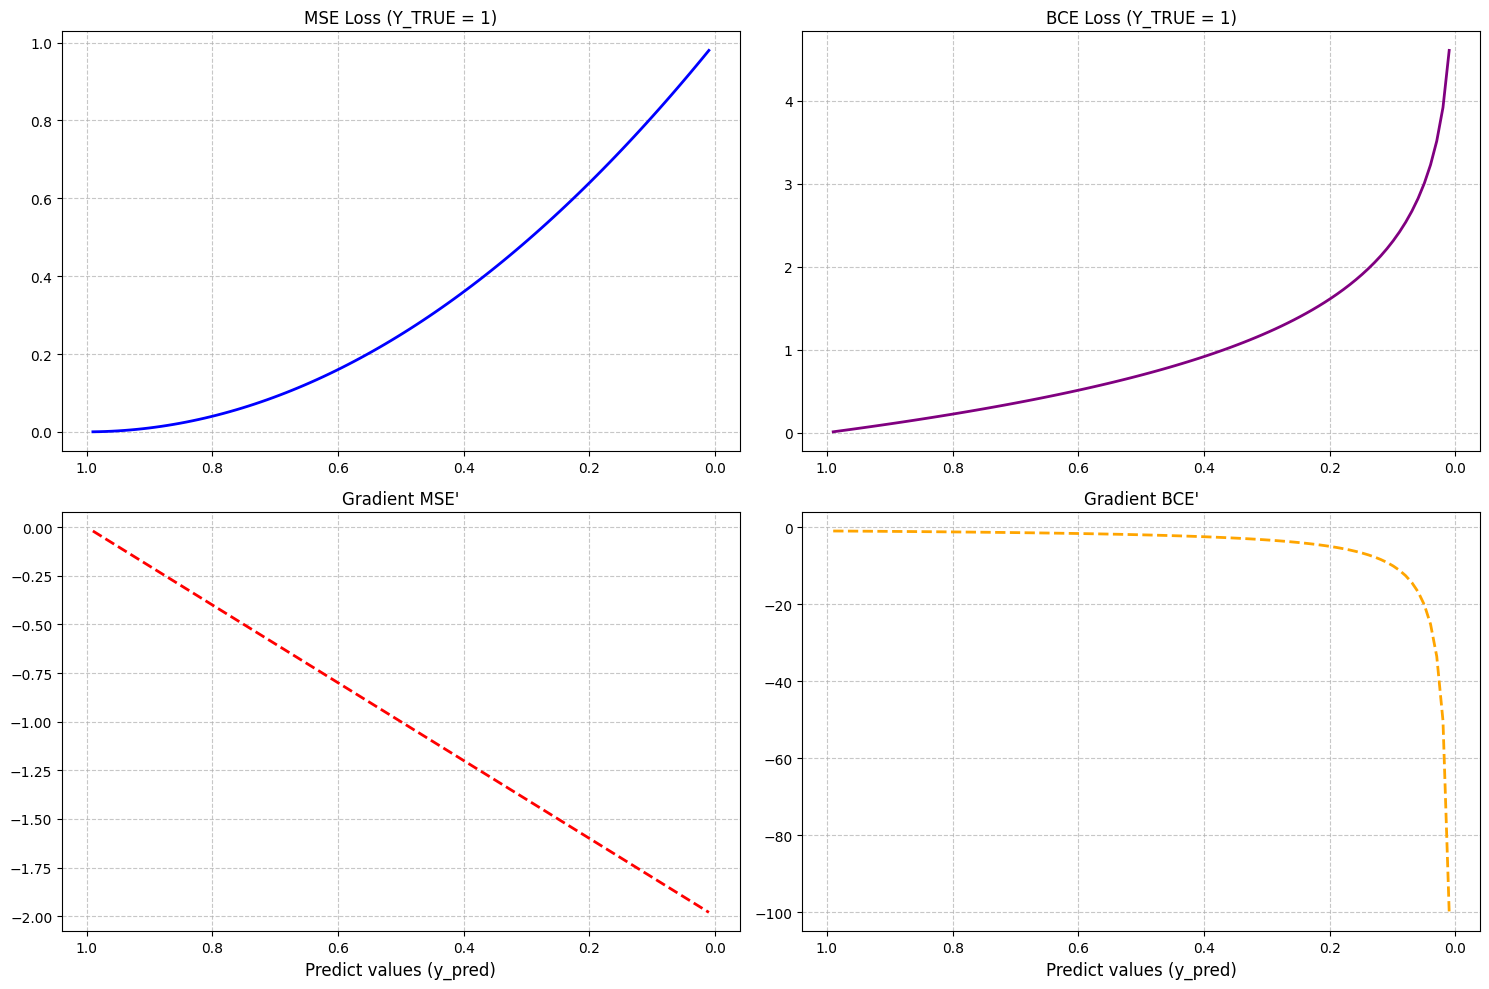

In [12]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))

ax1.plot(y_pre, mse_values, color='blue', linewidth=2)
ax1.set_title('MSE Loss (Y_TRUE = 1)', fontsize=12)
ax1.invert_xaxis()
ax1.grid(linestyle='--', alpha=0.7)

ax2.plot(y_pre, bce_values, color='purple', linewidth=2)
ax2.set_title('BCE Loss (Y_TRUE = 1)', fontsize=12)
ax2.invert_xaxis()
ax2.grid(linestyle='--', alpha=0.7)


ax3.plot(y_pre, mse_grads, color='red', linestyle='--', linewidth=2)
ax3.set_title("Gradient MSE'", fontsize=12)
ax3.set_xlabel('Predict values (y_pred)', fontsize=12)
ax3.invert_xaxis()
ax3.grid(linestyle='--', alpha=0.7)

ax4.plot(y_pre, bce_grads, color='orange', linestyle='--', linewidth=2)
ax4.set_title("Gradient BCE'", fontsize=12)
ax4.set_xlabel('Predict values (y_pred)', fontsize=12)
ax4.invert_xaxis()
ax4.grid(linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## 3. Key insight

**Key of MSE**
* **Observation:** Even when the model is completely wrong (predicting $y_{pre} \to 0$ when $y_{true}=1$), the MSE loss grow slowly and reach at $1.0$. The gradient is simple linear slope.
* **Conclusion:** MSE penalizes wrong predictions to slightly. If neuron network is completely wrong, the error signal (gradient) propagating back to update weights is very small. So that the model learn slowly.

**Key of MSE**
* **Observation:** When the model is completely wrong (predicting $y_{pre} \to 0$), the BCE loss grow significant to infinity, the gradient also grow significant to negative infinity.
* **Conclusion:** BCE penalizes harshly models that are **Confident Wrong** (such as 99% sure about wrong answer). It sends a super big error signal, force weights and bias change immediately to fix errors.